In [2]:
import polars as pl

In [3]:
alpr = pl.read_csv("../data/raw/alpr_cameras.csv")
crime_2017 = pl.read_csv("../data/raw/chicago_crime_2017.csv")
crime_2026 = pl.read_csv("../data/raw/chicago_crime_2026.csv")

In [4]:
print("ALPR cameras:", alpr.shape)
print("Chicago crime 2017:", crime_2017.shape)
print("Chicago crime 2026:", crime_2026.shape)

ALPR cameras: (101085, 4)
Chicago crime 2017: (269349, 22)
Chicago crime 2026: (167474, 22)


In [5]:
alpr.unique().shape

(101085, 4)

In [6]:
alpr.schema

Schema([('id', Int64), ('lat', Float64), ('lon', Float64), ('flock', Int64)])

In [7]:
alpr.head()

id,lat,lon,flock
i64,f64,f64,i64
109284,59.946735,10.720863,0
109296,59.946499,10.720669,0
212781,52.530543,-1.912191,0
2110144,48.033363,10.429899,0
10527370,59.878122,10.819904,0


In [8]:
alpr.null_count()

id,lat,lon,flock
u32,u32,u32,u32
0,0,0,0


In [9]:
alpr.group_by("flock").len()

flock,len
i64,u32
1,75614
0,25471


In [10]:
flock_counts = alpr.group_by("flock").len()

flock_counts = flock_counts.with_columns(
    (pl.col("len") / alpr.height * 100).alias("percentage")
)

flock_counts

flock,len,percentage
i64,u32,f64
1,75614,74.802394
0,25471,25.197606


In [11]:
alpr.describe()

statistic,id,lat,lon,flock
str,f64,f64,f64,f64
"""count""",101085.0,101085.0,101085.0,101085.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",1.2934e10,37.011819,-85.425932,0.748024
"""std""",1.3991e9,8.174374,33.633597,0.43415
"""min""",109284.0,-51.618136,-159.578685,0.0
"""25%""",1.2877e10,33.458897,-97.783876,0.0
"""50%""",1.3305e10,37.536903,-87.746075,1.0
"""75%""",1.3463e10,41.178379,-81.494288,1.0
"""max""",1.3779e10,69.681868,176.220261,1.0


In [12]:
alpr.select(
    pl.col("id").n_unique().alias("unique_ids"),
    pl.len().alias("total_rows")
)

unique_ids,total_rows
u32,u32
101085,101085


In [13]:
alpr.filter(
    (pl.col("lat") < -90) |
    (pl.col("lat") > 90) |
    (pl.col("lon") < -180) |
    (pl.col("lon") > 180)
).shape

(0, 4)

In [14]:
alpr.select("flock").unique().sort("flock")

flock
i64
0
1


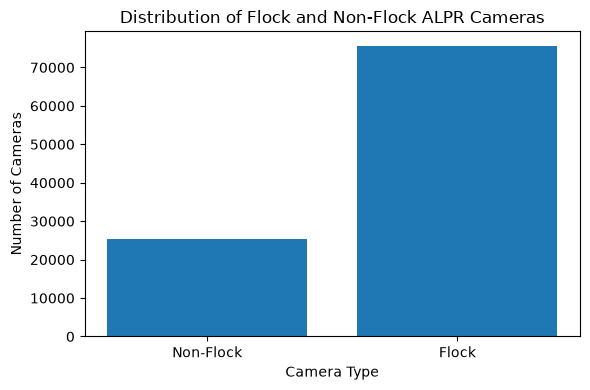

In [15]:
import matplotlib.pyplot as plt

flock_counts = (
    alpr
    .group_by("flock")
    .len()
    .sort("flock")
)

plt.figure(figsize=(6, 4))
plt.bar(
    ["Non-Flock", "Flock"],
    flock_counts["len"]
)

plt.xlabel("Camera Type")
plt.ylabel("Number of Cameras")
plt.title("Distribution of Flock and Non-Flock ALPR Cameras")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The ALPR dataset contains substantially more Flock cameras than non-Flock cameras. Of the 101,085 records, 75,614 (74.8%) are identified as Flock cameras and 25,471 (25.2%) are identified as non-Flock cameras. This distribution is important because the research focuses specifically on Flock cameras. The dataset is not evenly divided between the two groups, so comparisons between Flock and non-Flock cameras should account for this difference

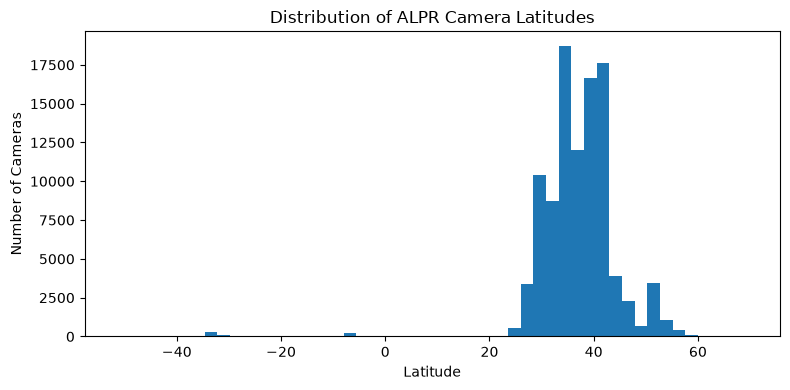

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(alpr["lat"], bins=50)

plt.xlabel("Latitude")
plt.ylabel("Number of Cameras")
plt.title("Distribution of ALPR Camera Latitudes")
plt.tight_layout()
plt.show()

The latitude distribution shows that the ALPR cameras are spread across a wide geographic range rather than being limited to Chicago. The distribution is centered around the mid-latitudes but includes cameras across multiple regions. This confirms that the dataset contains geographic data beyond the Chicago area, so the analysis will need to filter or focus on Chicago when examining the relationship between cameras and crime.

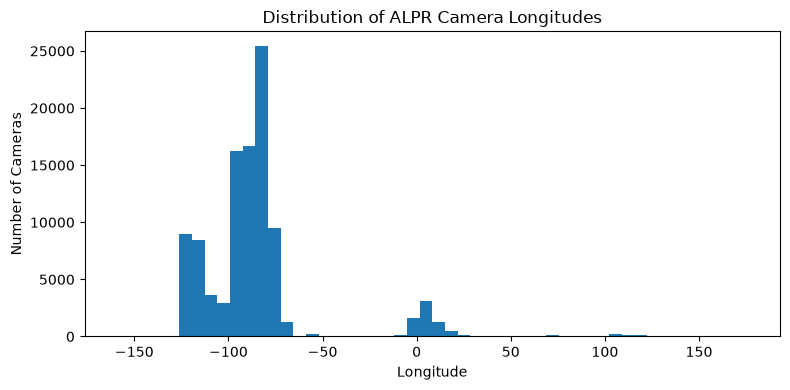

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(alpr["lon"], bins=50)

plt.xlabel("Longitude")
plt.ylabel("Number of Cameras")
plt.title("Distribution of ALPR Camera Longitudes")
plt.tight_layout()
plt.show()

The longitude distribution also shows that the ALPR dataset covers a broad geographic area. The wide spread of longitude values indicates that the dataset is not Chicago-specific. For the research questions, the Chicago subset will be more relevant when comparing camera locations with Chicago crime data.

In [18]:
crime_2017.schema

Schema([('ID', Int64),
        ('Case Number', String),
        ('Date', String),
        ('Block', String),
        ('IUCR', String),
        ('Primary Type', String),
        ('Description', String),
        ('Location Description', String),
        ('Arrest', Boolean),
        ('Domestic', Boolean),
        ('Beat', Int64),
        ('District', Int64),
        ('Ward', Int64),
        ('Community Area', Int64),
        ('FBI Code', String),
        ('X Coordinate', Int64),
        ('Y Coordinate', Int64),
        ('Year', Int64),
        ('Updated On', String),
        ('Latitude', Float64),
        ('Longitude', Float64),
        ('Location', String)])

In [19]:
crime_2017.head()

ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
i64,str,str,str,str,str,str,str,bool,bool,i64,i64,i64,i64,str,i64,i64,i64,str,f64,f64,str
11192233,"""JB100016""","""12/31/2017 11:58:00 PM""","""046XX N ST LOUIS AVE""","""0630""","""BURGLARY""","""ATTEMPT FORCIBLE ENTRY""","""APARTMENT""",false,false,1723,17,33,14,"""05""",1152214,1930694,2017,"""2018 May 04 03:51:04 PM""",41.965694,-87.715726,"""POINT (-87.715726125 41.965693…"
11196379,"""JB105867""","""12/31/2017 11:50:00 PM""","""024XX N LAKE SHORE DR NB""","""0460""","""BATTERY""","""SIMPLE""","""MOVIE HOUSE/THEATER""",false,false,1935,19,43,7,"""08B""",1175293,1916610,2017,"""2018 May 04 03:51:04 PM""",41.926559,-87.631294,"""POINT (-87.631294073 41.926558…"
11192540,"""JB100551""","""12/31/2017 11:48:00 PM""","""001XX E SUPERIOR ST""","""0890""","""THEFT""","""FROM BUILDING""","""HOTEL/MOTEL""",false,false,1833,18,42,8,"""06""",1177508,1905401,2017,"""2018 May 04 03:51:04 PM""",41.895751,-87.623496,"""POINT (-87.623495923 41.895750…"
11192254,"""JB100003""","""12/31/2017 11:45:00 PM""","""115XX S STATE ST""","""041A""","""BATTERY""","""AGGRAVATED: HANDGUN""","""RESIDENCE""",false,true,522,5,34,53,"""04B""",1178329,1828012,2017,"""2018 May 04 03:51:04 PM""",41.683369,-87.62283,"""POINT (-87.622829524 41.683369…"
11192239,"""JB100032""","""12/31/2017 11:45:00 PM""","""019XX S CANAL ST""","""1320""","""CRIMINAL DAMAGE""","""TO VEHICLE""","""STREET""",false,true,1235,12,25,31,"""14""",1173432,1891037,2017,"""2018 May 04 03:51:04 PM""",41.856427,-87.638893,"""POINT (-87.638892854 41.856426…"


In [20]:
crime_2017.null_count()

ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,1375,0,0,0,1,1,15,0,4413,4413,0,0,4413,4413,4413


In [21]:
crime_2017.describe()

statistic,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
str,f64,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,str
"""count""",269349.0,"""269349""","""269349""","""269349""","""269349""","""269349""","""269349""","""267974""",269349.0,269349.0,269349.0,269348.0,269348.0,269334.0,"""269349""",264936.0,264936.0,269349.0,"""269349""",264936.0,264936.0,"""264936"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""1375""",0.0,0.0,0.0,1.0,1.0,15.0,"""0""",4413.0,4413.0,0.0,"""0""",4413.0,4413.0,"""4413"""
"""mean""",1.0989e7,null,null,null,null,null,null,null,0.19569,0.187615,1146.02382,11.231069,23.270546,36.54823,null,1.1649e6,1.8866e6,2017.0,null,41.844493,-87.670217,null
"""std""",572775.094851,null,null,null,null,null,null,null,null,null,701.534324,7.007049,14.144244,21.403236,null,16116.819936,31269.795858,0.0,null,0.085992,0.058674,null
"""min""",23059.0,"""G183384""","""01/01/2017 01:00:00 AM""","""0000X E 100TH PL""","""0110""","""ARSON""","""$500 AND UNDER""","""ABANDONED BUILDING""",0.0,0.0,111.0,1.0,0.0,0.0,"""01A""",1.094231e6,1.813909e6,2017.0,"""2017 Apr 01 03:50:38 PM""",41.644606,-87.928909,"""POINT (-87.524529465 41.701938…"
"""25%""",1.0909907e7,null,null,null,null,null,null,null,null,null,611.0,6.0,10.0,23.0,null,1.153371e6,1.859405e6,2017.0,null,41.769597,-87.712289,null
"""50%""",1.1012756e7,null,null,null,null,null,null,null,null,null,1031.0,10.0,24.0,32.0,null,1.166685e6,1.894131e6,2017.0,null,41.865287,-87.664028,null
"""75%""",1.1109038e7,null,null,null,null,null,null,null,null,null,1722.0,17.0,35.0,53.0,null,1.176502e6,1.909087e6,2017.0,null,41.906365,-87.62776,null
"""max""",1.4328126e7,"""Z582023""","""12/31/2017 12:55:00 PM""","""137XX S LEYDEN AVE""","""5132""","""WEAPONS VIOLATION""","""VIOLENT OFFENDER: FAIL TO REGI…","""YARD""",1.0,1.0,6100.0,61.0,50.0,77.0,"""26""",1.205119e6,1.951535e6,2017.0,"""2026 Sep 16 03:44:40 PM""",42.022671,-87.524529,"""POINT (-87.928909442 41.969002…"


In [22]:
crime_2017.shape

(269349, 22)

In [23]:
crime_2017.unique().shape

(269349, 22)

In [24]:
crime_2017.select(
    pl.col("ID").n_unique().alias("unique_ids"),
    pl.len().alias("total_rows")
)

unique_ids,total_rows
u32,u32
269349,269349


In [25]:
crime_2017.select("Year").unique()

Year
i64
2017


In [26]:
crime_2017.select(
    pl.col("Date").min().alias("earliest_date"),
    pl.col("Date").max().alias("latest_date")
)

earliest_date,latest_date
str,str
"""01/01/2017 01:00:00 AM""","""12/31/2017 12:55:00 PM"""


In [27]:
crime_types_2017 = (
    crime_2017
    .group_by("Primary Type")
    .len()
    .sort("len", descending=True)
)

crime_types_2017

Primary Type,len
str,u32
"""THEFT""",64388
"""BATTERY""",49241
"""CRIMINAL DAMAGE""",29045
"""DECEPTIVE PRACTICE""",19832
"""ASSAULT""",19306
…,…
"""CONCEALED CARRY LICENSE VIOLAT…",69
"""OTHER NARCOTIC VIOLATION""",11
"""PUBLIC INDECENCY""",10


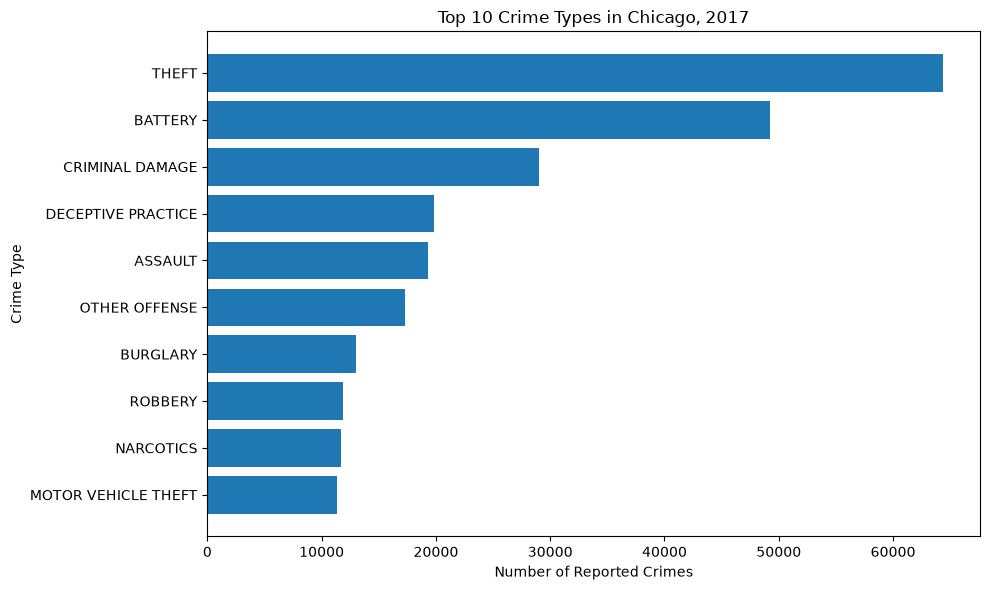

In [28]:
top_crimes_2017 = crime_types_2017.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_crimes_2017["Primary Type"][::-1],
    top_crimes_2017["len"][::-1]
)

plt.xlabel("Number of Reported Crimes")
plt.ylabel("Crime Type")
plt.title("Top 10 Crime Types in Chicago, 2017")
plt.tight_layout()
plt.show()

The distribution of reported crime types in 2017 is highly uneven. Theft and battery account for substantially more records than the other crime categories, while several categories occur much less frequently. This suggests that total crime counts are strongly influenced by a small number of common crime types. For later analysis, it may be useful to examine whether the relationship between Flock camera locations and crime differs across major crime categories rather than relying only on total crime.

In [29]:
crime_2017 = crime_2017.with_columns(
    pl.col("Date").str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias("Date")
)

crime_2017.select("Date").head()

Date
datetime[μs]
2017-12-31 23:58:00
2017-12-31 23:50:00
2017-12-31 23:48:00
2017-12-31 23:45:00
2017-12-31 23:45:00


In [30]:
monthly_crime_2017 = (
    crime_2017
    .with_columns(
        pl.col("Date").dt.month().alias("Month")
    )
    .group_by("Month")
    .len()
    .sort("Month")
)

monthly_crime_2017


Month,len
i8,u32
1,22247
2,19331
3,20603
4,21723
5,23412
…,…
8,24764
9,22874
10,22956


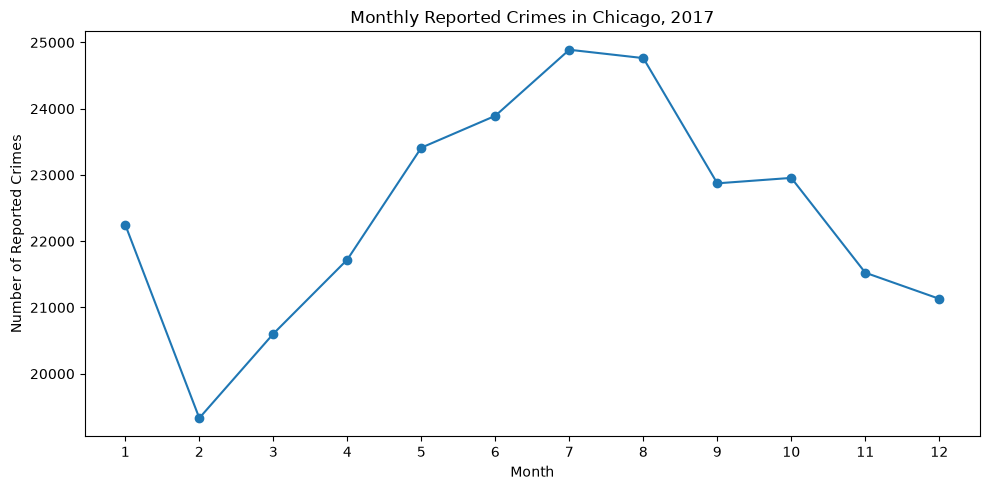

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_crime_2017["Month"],
    monthly_crime_2017["len"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Reported Crimes")
plt.title("Monthly Reported Crimes in Chicago, 2017")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

The number of reported crimes varies throughout 2017, with lower totals during some months and higher totals during the summer. July has the highest number of reported crimes, while February has one of the lowest totals. Overall, the monthly totals fluctuate but remain within a relatively similar range throughout the year, suggesting some seasonal variation without a dramatic change in total reported crime.

In [32]:
crime_2026.schema

Schema([('ID', Int64),
        ('Case Number', String),
        ('Date', String),
        ('Block', String),
        ('IUCR', String),
        ('Primary Type', String),
        ('Description', String),
        ('Location Description', String),
        ('Arrest', Boolean),
        ('Domestic', Boolean),
        ('Beat', Int64),
        ('District', Int64),
        ('Ward', Int64),
        ('Community Area', Int64),
        ('FBI Code', String),
        ('X Coordinate', Int64),
        ('Y Coordinate', Int64),
        ('Year', Int64),
        ('Updated On', String),
        ('Latitude', Float64),
        ('Longitude', Float64),
        ('Location', String)])

In [33]:
crime_2026.shape

(167474, 22)

In [34]:
crime_2026.head()

ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
i64,str,str,str,str,str,str,str,bool,bool,i64,i64,i64,i64,str,i64,i64,i64,str,f64,f64,str
14334571,"""JK421628""","""09/20/2026 12:00:00 AM""","""028XX S ARCHER AVE""","""1121""","""DECEPTIVE PRACTICE""","""COUNTERFEITING DOCUMENT""","""COMMERCIAL / BUSINESS OFFICE""",false,false,913,9,11,60,"""10""",1168555,1885790,2026,"""09/27/2026 03:42:09 PM""",41.842135,-87.656946,"""POINT (-87.656945593 41.842135…"
14333356,"""JK420268""","""09/20/2026 12:00:00 AM""","""088XX S LOWE AVE""","""1320""","""CRIMINAL DAMAGE""","""TO VEHICLE""","""STREET""",false,false,2223,22,21,71,"""14""",1173516,1846365,2026,"""09/27/2026 03:42:09 PM""",41.73384,-87.639907,"""POINT (-87.639907164 41.733840…"
14333481,"""JK420566""","""09/20/2026 12:00:00 AM""","""006XX N DEARBORN ST""","""0810""","""THEFT""","""OVER $500""","""STREET""",false,false,1832,18,42,8,"""06""",1175822,1904684,2026,"""09/27/2026 03:42:09 PM""",41.893822,-87.62971,"""POINT (-87.629709751 41.893821…"
14335903,"""JK423456""","""09/20/2026 12:00:00 AM""","""022XX S KEDZIE AVE""","""0760""","""BURGLARY""","""BURGLARY FROM MOTOR VEHICLE""","""STREET""",false,false,1024,10,24,30,"""06""",1155373,1888980,2026,"""09/27/2026 03:42:09 PM""",41.851164,-87.705234,"""POINT (-87.705234173 41.851163…"
14335596,"""JK423038""","""09/20/2026 12:00:00 AM""","""017XX N WELLS ST""","""1152""","""DECEPTIVE PRACTICE""","""ILLEGAL USE CASH CARD""","""STREET""",false,false,1814,18,43,7,"""11""",1174387,1911687,2026,"""09/27/2026 03:42:09 PM""",41.91307,-87.634771,"""POINT (-87.634770532 41.913070…"


In [35]:
crime_2026.null_count()

ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,758,0,0,0,0,0,1,0,304,304,0,0,304,304,304


In [36]:
crime_2026.describe()

statistic,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
str,f64,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,str
"""count""",167474.0,"""167474""","""167474""","""167474""","""167474""","""167474""","""167474""","""166716""",167474.0,167474.0,167474.0,167474.0,167474.0,167473.0,"""167474""",167170.0,167170.0,167474.0,"""167474""",167170.0,167170.0,"""167170"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""758""",0.0,0.0,0.0,0.0,0.0,1.0,"""0""",304.0,304.0,0.0,"""0""",304.0,304.0,"""304"""
"""mean""",1.4178e7,null,null,null,null,null,null,null,0.154723,0.192943,1149.787692,11.266495,22.882023,36.178614,null,1.1657e6,1.8871e6,2026.0,null,41.845748,-87.667339,null
"""std""",618808.403252,null,null,null,null,null,null,null,null,null,733.252494,7.325052,13.910744,21.358622,null,16200.262567,31198.193219,0.0,null,0.085795,0.058985,null
"""min""",29000.0,"""HK572868""","""01/01/2026 01:00:00 AM""","""0000X E 100TH PL""","""0110""","""ARSON""","""$500 AND UNDER""","""ABANDONED BUILDING""",0.0,0.0,111.0,1.0,0.0,0.0,"""01A""",1.094587e6,1.813897e6,2026.0,"""01/13/2026 03:57:41 PM""",41.64459,-87.927365,"""POINT (-87.524529378 41.702237…"
"""25%""",1.4139749e7,null,null,null,null,null,null,null,null,null,531.0,5.0,10.0,22.0,null,1.154475e6,1.860263e6,2026.0,null,41.772017,-87.708254,null
"""50%""",1.4204381e7,null,null,null,null,null,null,null,null,null,1032.0,10.0,23.0,32.0,null,1.167644e6,1.893598e6,2026.0,null,41.863751,-87.659958,null
"""75%""",1.4269916e7,null,null,null,null,null,null,null,null,null,1731.0,17.0,34.0,53.0,null,1.176961e6,1.909734e6,2026.0,null,41.908176,-87.626156,null
"""max""",1.4340599e7,"""JL192999""","""09/20/2026 12:00:00 AM""","""137XX S LEYDEN AVE""","""5132""","""WEAPONS VIOLATION""","""WIC FRAUD""","""YARD""",1.0,1.0,6100.0,61.0,50.0,77.0,"""26""",1.205116e6,1.951495e6,2026.0,"""09/27/2026 03:42:09 PM""",42.022548,-87.524529,"""POINT (-87.927364891 42.006074…"


### What Stands Out

* **167,474 crime records** are included in the dataset.
* The data covers **January 1, 2026 through September 20, 2026** based on the Date field.
* The Year column is consistently **2026**.
* About **15.5%** of reported crimes resulted in an arrest.
* About **19.3%** of reported crimes are marked as domestic.
* Latitude ranges from approximately **41.64 to 42.02**.
* Longitude ranges from approximately **-87.93 to -87.52**, which is consistent with the Chicago area.
* There are **758 missing Location Description** values.
* There is **1 missing Community Area** value.
* **304 records** are missing geographic coordinates and location information.
* The Date and Updated On columns are stored as strings, so Date should be converted to a datetime format before performing time-based analysis.
* The dataset does **not cover the complete 2026 year**, so it should be treated as **2026 year-to-date (YTD)** when making comparisons. It should not be directly compared with the full-year 2017 crime total without accounting for the different time periods.


In [37]:
crime_2026.unique().shape

(167474, 22)

In [38]:
crime_2026.select(
    pl.col("ID").n_unique().alias("unique_ids"),
    pl.len().alias("total_rows")
)

unique_ids,total_rows
u32,u32
167474,167474


No Duplicate rows

In [39]:
crime_2026.select("Year").unique().sort("Year")

Year
i64
2026


Year check is good

In [40]:
crime_2026.filter(
    (pl.col("Latitude") < -90) |
    (pl.col("Latitude") > 90) |
    (pl.col("Longitude") < -180) |
    (pl.col("Longitude") > 180)
).shape

(0, 22)

No invalid coords

In [41]:
crime_types_2026 = (
    crime_2026
    .group_by("Primary Type")
    .len()
    .sort("len", descending=True)
)

crime_types_2026

Primary Type,len
str,u32
"""THEFT""",36122
"""BATTERY""",30875
"""CRIMINAL DAMAGE""",18368
"""ASSAULT""",15194
"""MOTOR VEHICLE THEFT""",13211
…,…
"""HUMAN TRAFFICKING""",25
"""PUBLIC INDECENCY""",18
"""GAMBLING""",13


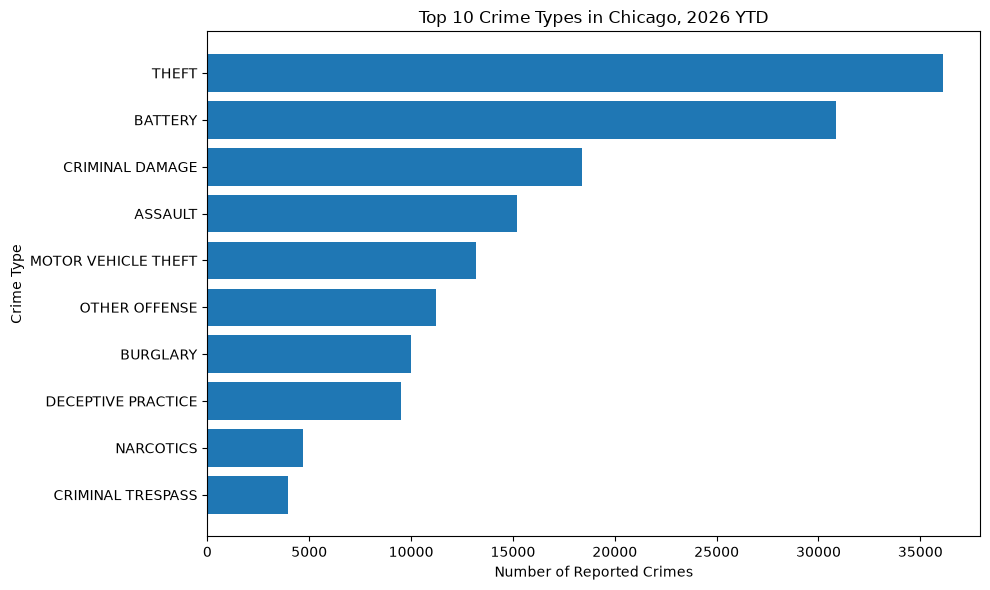

In [42]:
top_crimes_2026 = crime_types_2026.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_crimes_2026["Primary Type"][::-1],
    top_crimes_2026["len"][::-1]
)
plt.xlabel("Number of Reported Crimes")
plt.ylabel("Crime Type")
plt.title("Top 10 Crime Types in Chicago, 2026 YTD")
plt.tight_layout()
plt.show()

The distribution of reported crime types in Chicago in 2026 YTD is highly uneven. Theft and battery are the most common reported crime types, followed by criminal damage, assault, and motor vehicle theft. Several other crime categories occur much less frequently. This shows that a small number of crime types account for a large portion of reported crimes. This is important for later analysis because the relationship between Flock cameras and crime may differ depending on the type of crime being examined.

In [43]:
crime_2026 = crime_2026.with_columns(
    pl.col("Date").str.to_datetime(
        "%m/%d/%Y %I:%M:%S %p"
    ).alias("Date")
)

crime_2026.select("Date").head()

Date
datetime[μs]
2026-09-20 00:00:00
2026-09-20 00:00:00
2026-09-20 00:00:00
2026-09-20 00:00:00
2026-09-20 00:00:00


In [44]:
monthly_crime_2026 = (
    crime_2026
    .with_columns(
        pl.col("Date").dt.month().alias("Month")
    )
    .group_by("Month")
    .len()
    .sort("Month")
)

monthly_crime_2026

Month,len
i8,u32
1,17030
2,16542
3,19178
4,19140
5,21143
6,20030
7,21233
8,20715
9,12463


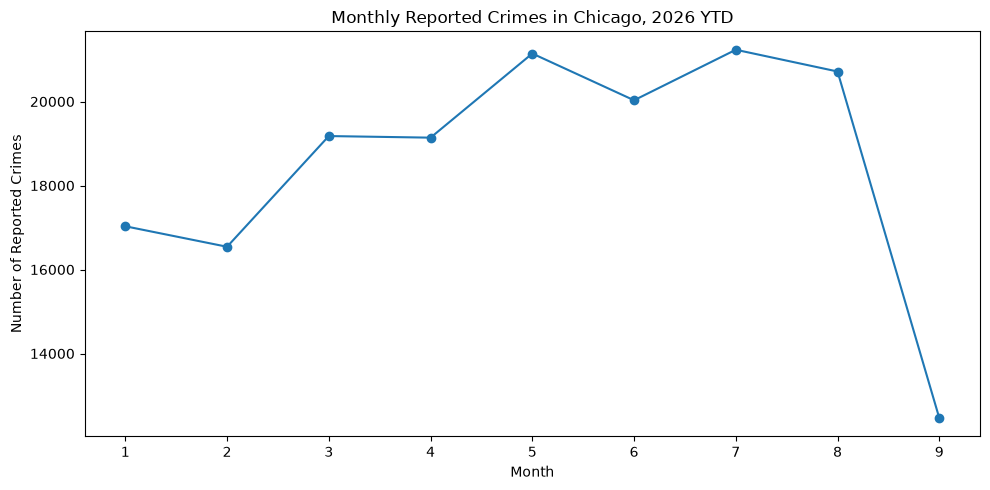

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_crime_2026["Month"],
    monthly_crime_2026["len"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Reported Crimes")
plt.title("Monthly Reported Crimes in Chicago, 2026 YTD")
plt.xticks(range(1, 10))
plt.tight_layout()
plt.show()

Reported crime counts vary across the months included in the 2026 YTD dataset. Crime counts generally increase from January through July, with July having the highest number of reported crimes among the complete months. August remains relatively high, while September has a noticeably lower count. But, September only includes incidents through September 20, so its lower total should not be interpreted as a true decrease in crime. Overall, the monthly distribution shows some variation throughout the year, but the partial September data limits comparisons for that month.

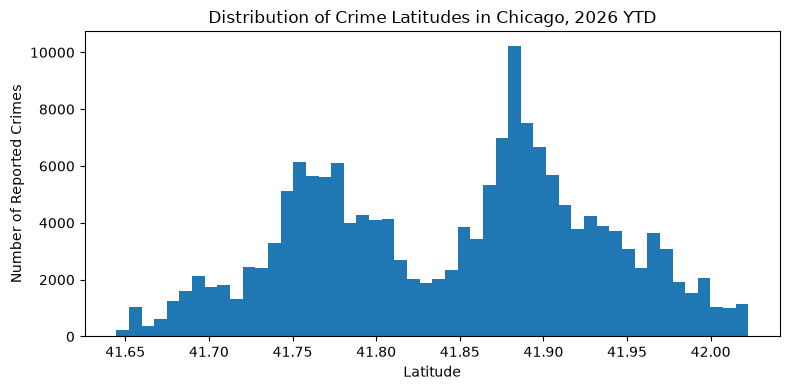

In [46]:
plt.figure(figsize=(8, 4))

plt.hist(crime_2026["Latitude"].drop_nulls(), bins=50)

plt.xlabel("Latitude")
plt.ylabel("Number of Reported Crimes")
plt.title("Distribution of Crime Latitudes in Chicago, 2026 YTD")
plt.tight_layout()
plt.show()

The latitude values are concentrated within a relatively narrow range, which is expected because the dataset represents reported crimes within Chicago. The distribution shows where reported crimes are geographically concentrated from north to south. There are no invalid latitude values, although 304 records have missing geographic coordinates and are excluded from this plot.

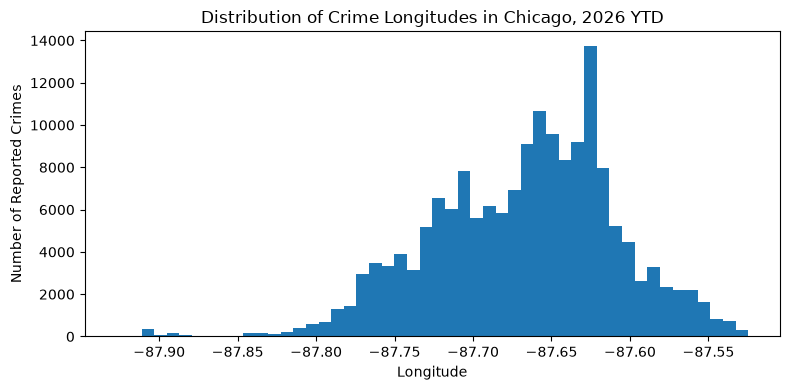

In [47]:
plt.figure(figsize=(8, 4))

plt.hist(crime_2026["Longitude"].drop_nulls(), bins=50)

plt.xlabel("Longitude")
plt.ylabel("Number of Reported Crimes")
plt.title("Distribution of Crime Longitudes in Chicago, 2026 YTD")
plt.tight_layout()
plt.show()

The longitude values are concentrated within a relatively narrow range, which is expected because the dataset represents reported crimes within Chicago. The distribution shows how reported crimes are geographically distributed from west to east across the city. There are no invalid longitude values, although 304 records have missing geographic coordinates and are excluded from this plot.

In [48]:
alpr_chicago = alpr.filter(
    (pl.col("lat") >= 41.64) &
    (pl.col("lat") <= 42.03) &
    (pl.col("lon") >= -87.94) &
    (pl.col("lon") <= -87.52)
)

alpr_chicago.shape

(1101, 4)

In [49]:
chicago_camera_types = (
    alpr_chicago
    .group_by("flock")
    .len()
    .sort("flock")
)

chicago_camera_types

flock,len
i64,u32
0,619
1,482


In [50]:
crime_2026_geo = crime_2026.filter(
    pl.col("Latitude").is_not_null() &
    pl.col("Longitude").is_not_null()
)

crime_2026_geo.shape

(167170, 22)

In [51]:
flock_chicago = alpr_chicago.filter(
    pl.col("flock") == 1
)

flock_chicago.shape

(482, 4)

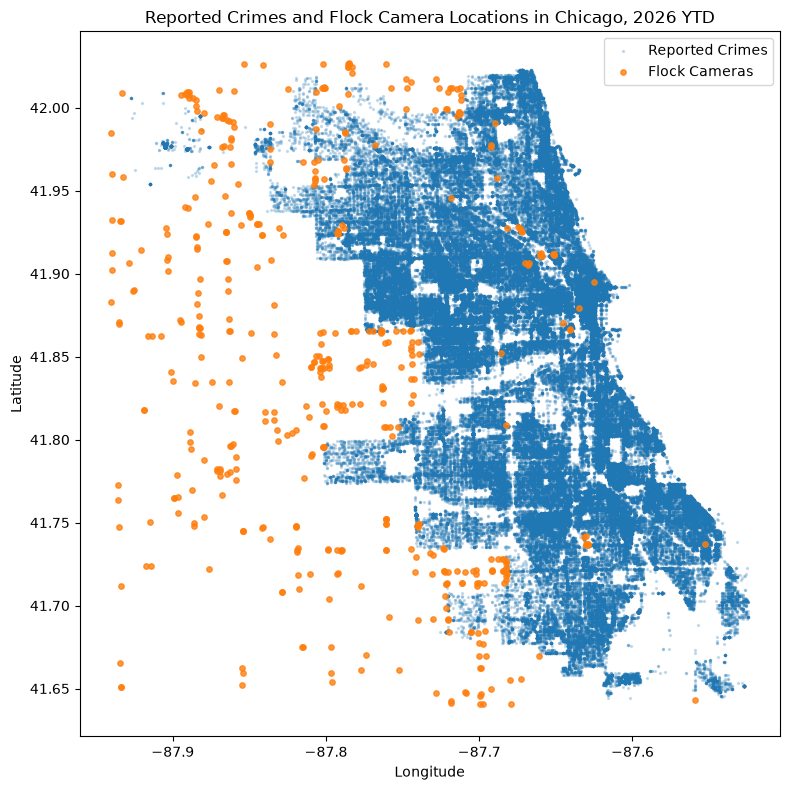

In [52]:
plt.figure(figsize=(8, 8))

plt.scatter(
    crime_2026_geo["Longitude"],
    crime_2026_geo["Latitude"],
    s=2,
    alpha=0.2,
    label="Reported Crimes"
)

plt.scatter(
    flock_chicago["lon"],
    flock_chicago["lat"],
    s=15,
    alpha=0.8,
    label="Flock Cameras"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Reported Crimes and Flock Camera Locations in Chicago, 2026 YTD")
plt.legend()
plt.tight_layout()
plt.show()

The spatial distribution shows some overlap between reported crime and Flock camera locations. Several Flock cameras appear in areas with higher concentrations of reported crime, but many cameras are also located outside the densest crime clusters. This suggests that camera placement is not determined solely by reported crime density. However, this plot is descriptive and does not measure the strength of the relationship statistically.

A useful next step is to compare the number of Flock cameras with the number of reported crimes across smaller geographic areas within Chicago. This would allow us to determine whether areas with more Flock cameras also tend to have more reported crime.

In [53]:
monthly_crime_arrest_2026 = (
    crime_2026
    .with_columns(
        pl.col("Date").dt.month().alias("Month")
    )
    .group_by("Month")
    .agg([
        pl.len().alias("Crime Count"),
        pl.col("Arrest").mean().alias("Arrest Rate")
    ])
    .sort("Month")
)

monthly_crime_arrest_2026

Month,Crime Count,Arrest Rate
i8,u32,f64
1,17030,0.167645
2,16542,0.166002
3,19178,0.155647
4,19140,0.151881
5,21143,0.14156
6,20030,0.155317
7,21233,0.157161
8,20715,0.151822
9,12463,0.147075


In [55]:
crime_type_arrest_2026 = (
    crime_2026
    .group_by("Primary Type")
    .agg([
        pl.len().alias("Crime Count"),
        pl.col("Arrest").mean().alias("Arrest Rate")
    ])
    .sort("Crime Count", descending=True)
)

crime_type_arrest_2026

Primary Type,Crime Count,Arrest Rate
str,u32,f64
"""THEFT""",36122,0.08989
"""BATTERY""",30875,0.192939
"""CRIMINAL DAMAGE""",18368,0.045949
"""ASSAULT""",15194,0.136567
"""MOTOR VEHICLE THEFT""",13211,0.037166
…,…,…
"""HUMAN TRAFFICKING""",25,0.0
"""PUBLIC INDECENCY""",18,0.888889
"""GAMBLING""",13,1.0


In [56]:
top_crime_arrest_2026 = (
    crime_type_arrest_2026
    .head(10)
    .sort("Arrest Rate", descending=True)
)

top_crime_arrest_2026

Primary Type,Crime Count,Arrest Rate
str,u32,f64
"""NARCOTICS""",4714,0.9493
"""CRIMINAL TRESPASS""",3981,0.333585
"""BATTERY""",30875,0.192939
"""OTHER OFFENSE""",11224,0.166429
"""ASSAULT""",15194,0.136567
"""THEFT""",36122,0.08989
"""CRIMINAL DAMAGE""",18368,0.045949
"""MOTOR VEHICLE THEFT""",13211,0.037166
"""BURGLARY""",10004,0.028289


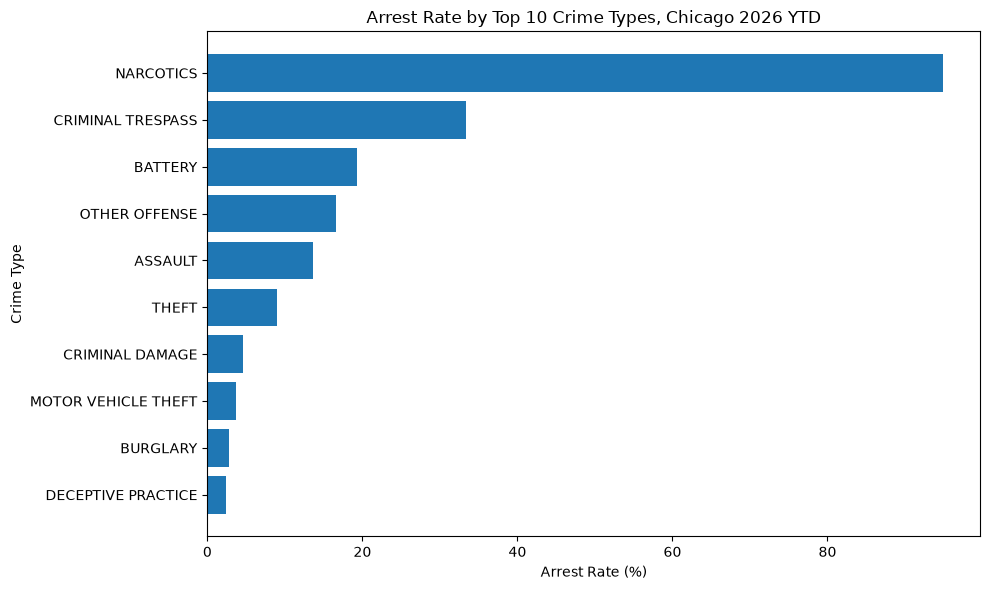

In [57]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_crime_arrest_2026["Primary Type"][::-1],
    top_crime_arrest_2026["Arrest Rate"][::-1] * 100
)

plt.xlabel("Arrest Rate (%)")
plt.ylabel("Crime Type")
plt.title("Arrest Rate by Top 10 Crime Types, Chicago 2026 YTD")
plt.tight_layout()
plt.show()

The arrest rate varies substantially across the most common crime types in Chicago in 2026 YTD. Narcotics has a much higher arrest rate than the other crime types, at about 94.9%. Criminal trespass also has a relatively high arrest rate at about 33.4%, while common crimes such as theft, criminal damage, motor vehicle theft, burglary, and deceptive practice have much lower arrest rates. This shows that the likelihood of an arrest varies considerably depending on the type of crime reported. However, this relationship does not tell us whether Flock cameras contributed to arrests or crime outcomes.



A useful next step is to examine whether the relationship between Flock camera locations and reported crime differs across crime types. For example, we could compare the locations of Flock cameras with areas where specific common crimes, such as theft, battery, or motor vehicle theft, are frequently reported. This could help determine whether camera placement overlaps more strongly with certain types of reported crime.

In [58]:
grid_size = 0.02

flock_grid = (
    flock_chicago
    .with_columns([
        (pl.col("lat") / grid_size).floor().alias("lat_grid"),
        (pl.col("lon") / grid_size).floor().alias("lon_grid")
    ])
    .group_by(["lat_grid", "lon_grid"])
    .len()
    .rename({"len": "Flock Cameras"})
)

crime_grid = (
    crime_2026_geo
    .with_columns([
        (pl.col("Latitude") / grid_size).floor().alias("lat_grid"),
        (pl.col("Longitude") / grid_size).floor().alias("lon_grid")
    ])
    .group_by(["lat_grid", "lon_grid"])
    .len()
    .rename({"len": "Reported Crimes"})
)

In [59]:
camera_crime_grid = (
    crime_grid
    .join(
        flock_grid,
        on=["lat_grid", "lon_grid"],
        how="left"
    )
    .with_columns(
        pl.col("Flock Cameras").fill_null(0)
    )
)

camera_crime_grid

lat_grid,lon_grid,Reported Crimes,Flock Cameras
f64,f64,u32,u32
2097.0,-4392.0,143,0
2084.0,-4379.0,28,0
2094.0,-4386.0,2222,0
2084.0,-4383.0,880,0
2087.0,-4384.0,1331,0
…,…,…,…
2089.0,-4384.0,1203,0
2085.0,-4379.0,553,0
2091.0,-4386.0,263,0


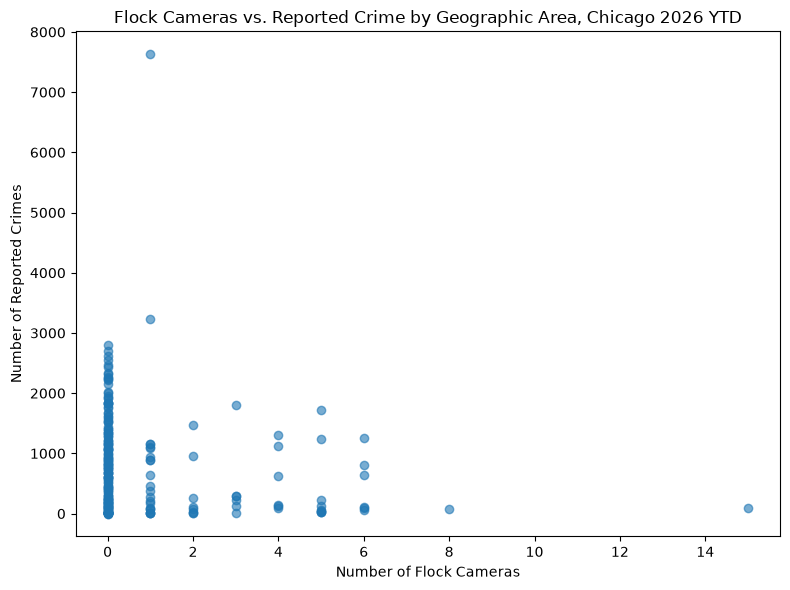

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    camera_crime_grid["Flock Cameras"],
    camera_crime_grid["Reported Crimes"],
    alpha=0.6
)

plt.xlabel("Number of Flock Cameras")
plt.ylabel("Number of Reported Crimes")
plt.title("Flock Cameras vs. Reported Crime by Geographic Area, Chicago 2026 YTD")
plt.tight_layout()
plt.show()

The scatter plot suggests a weak and inconsistent relationship between the number of Flock cameras and reported crime. Areas with few or no Flock cameras show a wide range of reported crime levels, including some of the highest crime counts. As the number of cameras increases, there is no clear upward or downward trend in reported crime. This suggests that the number of Flock cameras in a geographic area is not strongly associated with the number of reported crimes. This is important because it suggests that simply having more Flock cameras in an area does not necessarily correspond to having more reported crime.

A useful next step would be to examine whether this relationship changes for specific types of crime, such as motor vehicle theft, theft, or battery. This could show whether Flock cameras are more commonly located in areas with certain types of reported crime rather than overall crime.

## Revised Research Questions


**What relationship exists between the geographic distribution of Flock Safety ALPR cameras and reported crime in Chicago in 2026?**

also considering the following questions:

1. Are Flock cameras located in areas with higher concentrations of reported crime?
2. Does the relationship between Flock cameras and reported crime vary across different types of crime?
3. How does reported crime vary across different geographic areas of Chicago?

## Overall Findings

The exploratory analysis shows that Flock cameras and reported crime have some geographic overlap in Chicago, but the number of Flock cameras in an area does not show a strong or consistent relationship with the number of reported crimes. Areas with few or no Flock cameras can still have high numbers of reported crimes.

Crime types also have substantially different arrest rates. Narcotics has a much higher arrest rate than the other common crime categories, while crimes such as theft, burglary, and motor vehicle theft have relatively low arrest rates.

The analysis also identified missing geographic information in the crime datasets. These records were retained in the original datasets but excluded from geographic plots when latitude or longitude was missing. The 2026 crime dataset only covers January through September 20, 2026, so it should be treated as year-to-date data rather than a complete year.

These findings suggest that Flock camera placement should be examined more closely by crime type and geographic area rather than assuming that more cameras correspond to more reported crime.
